<a href="https://colab.research.google.com/github/Diviyah13/Apple-Orange-Computer-Vision-/blob/main/Apple_Orange_Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**POST MODULE ASSESSMENT**

NAME: Diviyah Kumara Rajah (MRT254029)

CLASS SECTION: MRTB2153-50

LECT. NAME: Mohd Syahid bin Mohd Anuar

Collab Link: https://colab.research.google.com/drive/11E_o_8YQ041X50ryn1DQvktvoWfZwG10?usp=sharing

# Part A: Dataset Design & Preparation


Apple vs Orange. Apples and oranges share a similar round shape and size, making shape-based discrimination unreliable, while they differ significantly in color (red/green vs orange) and surface texture (smooth waxy skin vs dimpled rind), making color and texture the primary discriminative features. We are testing whether models rely on color cues alone or robust feature combinations.

Classification dataset

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("moltean/fruits")

print("Dataset downloaded to:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'fruits' dataset.
Dataset downloaded to: /kaggle/input/fruits
['fruits-360_100x100', 'fruits-360_3-body-problem', 'fruits-360_meta', 'fruits-360_original-size', 'fruits-360_multi']


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

DATASET_DIR = path

CLASSIFICATION_SRC = os.path.join(
    DATASET_DIR,
    "fruits-360_100x100",
    "fruits-360",
    "Training"
)

OUTPUT_BASE = "/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/classification_processed"

print("Source path:", CLASSIFICATION_SRC)
print("Source exists:", os.path.exists(CLASSIFICATION_SRC))
print(os.listdir(CLASSIFICATION_SRC)[:20])

Source path: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
Source exists: True
['Melon Piel de Sapo 1', 'Dates 1', 'Avocado Black 2', 'Nectarine Flat 2', 'Apple Crimson Snow 1', 'Cherry Wax 2', 'Onion Red 1', 'Cherry Wax Yellow 1', 'Pear 10', 'Cherry 3', 'Avocado Green 1', 'Pear Red 1', 'Potato Red 1', 'Apple 7', 'Cucumber 8', 'Quince 4', 'Pear 12', 'Tomato Cherry Red 2', 'Apple Red 3', 'Huckleberry 1']


### Class Filtering
The Fruits-360 dataset contains many sub-variety folders per fruit (e.g. "Apple Red 1", "Apple Golden 1", "Apple Braeburn 1").
I manually curated a `TARGET_CLASSES` mapping to merge only REAL apple/orange varieties into two unified classes, excluding visually similar but unrelated folders such as "Tomato Cherry Orange" and "Pepper Orange" which
contain "Orange" in their name but are not true oranges.

In [ ]:
for folder in os.listdir(CLASSIFICATION_SRC):
    if "Apple" in folder or "Orange" in folder:
        print(folder)

Apple Crimson Snow 1
Apple 7
Apple Red 3
Apple 18
Tomato Cherry Orange 1
Apple 5
Apple 17
Apple 13
Apple Red 2
Orange 3
Apple 12
Orange 2
Apple 19
Apple 11
Apple Golden 2
Apple 9
Pepper Orange 2
Apple Granny Smith 1
Apple Braeburn 1
Apple 10
Apple 23
Apple 6
Apple 22
Apple 21
Orange 1
Orange peeled 1
Apple 20
Apple Golden 3
Pepper Orange 1
Apple Red 1
Apple Red Delicious 1
Apple Golden 1
Apple Pink Lady 1
Apple 14
Apple Red Yellow 2
Apple Red Yellow 1
Apple 8


In [ ]:
TARGET_CLASSES = {
    "Apple": [
        "Apple Red 1",
        "Apple Red 2",
        "Apple Red 3",
        "Apple Golden 1",
        "Apple Braeburn 1",
        "Apple Granny Smith 1"
    ],
    "Orange": [
        "Orange 1",
        "Orange 2",
        "Orange 3"
    ]
}

In [ ]:
def create_directory_structure(base_path, classes):
    splits = ['train', 'val', 'test']

    for split in splits:
        for c in classes.keys():
            folder_path = os.path.join(base_path, split, c)
            os.makedirs(folder_path, exist_ok=True)

    print(f"Directory structure successfully created at: {base_path}")

create_directory_structure(OUTPUT_BASE, TARGET_CLASSES)

Directory structure successfully created at: /content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/classification_processed


In [19]:
def process_and_split_dataset(src_root, output_root, target_map, train_ratio=0.7, val_ratio=0.15):
    aggregated_images = {k: [] for k in target_map.keys()}

    for folder_name in os.listdir(src_root):
        for target_label, variants in target_map.items():
            if folder_name in variants:
                folder_path = os.path.join(src_root, folder_name)

                images = [
                    os.path.join(folder_path, f)
                    for f in os.listdir(folder_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                ]

                aggregated_images[target_label].extend(images)

    for label, image_paths in aggregated_images.items():
        print(f"Found {len(image_paths)} total images for category: {label}")

        random.seed(42)
        random.shuffle(image_paths)

        total = len(image_paths)
        train_end = int(total * train_ratio)
        val_end = train_end + int(total * val_ratio)

        splits = {
            'train': image_paths[:train_end],
            'val': image_paths[train_end:val_end],
            'test': image_paths[val_end:]
        }

        for split_name, paths in splits.items():
            dest_dir = os.path.join(output_root, split_name, label)
            print(f"Copying {len(paths)} images to {split_name}/{label}...")

            for p in tqdm(paths, desc=f"{split_name}-{label}"):
                filename = os.path.basename(p)
                parent_dir_name = os.path.basename(os.path.dirname(p))
                unique_filename = f"{parent_dir_name}_{filename}"

                shutil.copy2(
                    p,
                    os.path.join(dest_dir, unique_filename)
                )

process_and_split_dataset(
    CLASSIFICATION_SRC,
    OUTPUT_BASE,
    TARGET_CLASSES
)

Found 2877 total images for category: Apple
Copying 2013 images to train/Apple...


train-Apple: 100%|██████████| 2013/2013 [08:53<00:00,  3.77it/s]


Copying 431 images to val/Apple...


val-Apple: 100%|██████████| 431/431 [01:49<00:00,  3.92it/s]


Copying 433 images to test/Apple...


...

train-Orange: 100%|██████████| 1327/1327 [05:54<00:00,  3.75it/s]


Copying 284 images to val/Orange...


val-Orange: 100%|██████████| 284/284 [01:16<00:00,  3.72it/s]


Copying 286 images to test/Orange...


test-Orange: 100%|██████████| 286/286 [01:20<00:00,  3.57it/s]


In [21]:
for split in ['train', 'val', 'test']:
    for fruit in ['Apple', 'Orange']:
        folder = os.path.join(OUTPUT_BASE, split, fruit)
        print(split, fruit, len(os.listdir(folder)))

train Apple 2013
train Orange 1327
val Apple 431
val Orange 284
test Apple 433
test Orange 286


TRAIN_DIR = where training images are
VAL_DIR = where validation images are
TEST_DIR = where test images are

In [22]:
TRAIN_DIR = OUTPUT_BASE + "/train"
VAL_DIR = OUTPUT_BASE + "/val"
TEST_DIR = OUTPUT_BASE + "/test"

print("Train folder:", TRAIN_DIR)
print("Validation folder:", VAL_DIR)
print("Test folder:", TEST_DIR)

Train folder: /content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/classification_processed/train
Validation folder: /content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/classification_processed/val
Test folder: /content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/classification_processed/test


In [23]:
import os

for split_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(split_path)
    print(os.listdir(split_path))

/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/classification_processed/train
['Apple', 'Orange']
/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/classification_processed/val
['Apple', 'Orange']
/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/classification_processed/test
['Apple', 'Orange']


# Detection Dataset Preprocessing

In [ ]:
import kagglehub

detection_path = kagglehub.dataset_download("mbkinaci/fruit-images-for-object-detection")
print("Downloaded to:", detection_path)
print(os.listdir(detection_path))

Using Colab cache for faster access to the 'fruit-images-for-object-detection' dataset.
Downloaded to: /kaggle/input/fruit-images-for-object-detection
['train_zip', 'test_zip']


To find the actual images/XMLs.

In [ ]:
import os

for sub in ['test_zip', 'train_zip']:
    sub_path = os.path.join(detection_path, sub)
    print(f"\n--- {sub} ---")
    print(os.listdir(sub_path))


--- test_zip ---
['test']

--- train_zip ---
['train']


In [ ]:
# To check for XML files
inner_path = os.path.join(detection_path, 'train_zip', 'train')
print(os.listdir(inner_path)[:20])  # just first 20 to check file types

['banana_68.jpg', 'apple_46.jpg', 'apple_28.xml', 'orange_20.jpg', 'orange_22.xml', 'apple_65.xml', 'orange_41.xml', 'banana_67.xml', 'mixed_12.xml', 'banana_37.xml', 'mixed_1.jpg', 'apple_55.xml', 'mixed_20.xml', 'apple_70.xml', 'apple_68.jpg', 'banana_45.xml', 'orange_50.xml', 'banana_31.jpg', 'mixed_11.xml', 'apple_46.xml']


Structure confirmed:

train_zip/train/ — flat folder, images + matching XMLs together
test_zip/test/ — same structure
Filename patterns: apple_N, banana_N, orange_N, mixed_N

In [ ]:
xml_files = [f for f in os.listdir(inner_path) if f.endswith('.xml')]

# Check a single-fruit XML and a mixed XML
sample_single = [f for f in xml_files if f.startswith('apple')][0]
sample_mixed = [f for f in xml_files if f.startswith('mixed')][0]

print(f"--- {sample_single} ---")
with open(os.path.join(inner_path, sample_single)) as f:
    print(f.read())

print(f"\n--- {sample_mixed} ---")
with open(os.path.join(inner_path, sample_mixed)) as f:
    print(f.read())

--- apple_28.xml ---
<annotation>
	<folder>train</folder>
	<filename>apple_28.jpg</filename>
	<path>C:\tensorflow1\models\research\object_detection\images\train\apple_28.jpg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>0</width>
		<height>0</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>apple</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>25</xmin>
			<ymin>42</ymin>
			<xmax>275</xmax>
			<ymax>297</ymax>
		</bndbox>
	</object>
</annotation>


--- mixed_12.xml ---
<annotation>
	<folder>train</folder>
	<filename>mixed_12.jpg</filename>
	<path>C:\tensorflow1\models\research\object_detection\images\train\mixed_12.jpg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>1024</width>
		<height>637</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>orange</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>

Observation:

1. apple_44.xml — <width>0</width><height>0</height>. Many single-fruit XML files in this dataset have broken/zero width-height values . This would silently break YOLO normalization (division by zero) if we trust the XML's size tag.
The fix: read actual image dimensions directly from the image file using PIL/cv2 instead of trusting the XML
2. mixed_9.xml ,confirmed exactly as expected: real width/height (450×470) and objects in one image (orange, apple, banana), basket multi-fruit image with correct bounding boxes.

Full Preprocessing Script for Part C

In [ ]:
import os
import shutil
import random
from glob import glob
import xml.etree.ElementTree as ET
from PIL import Image
from tqdm import tqdm

# ---- CONFIG ----
TRAIN_SRC = os.path.join(detection_path, 'train_zip', 'train')
TEST_SRC = os.path.join(detection_path, 'test_zip', 'test')
OUTPUT_DIR = os.path.join("fruit_dataset", "detection_processed")

CLASS_MAP = {"apple": 0, "orange": 1}  # banana intentionally excluded

# Create YOLO folder structure
for folder in ['images', 'labels']:
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(OUTPUT_DIR, folder, split), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'basket_images'), exist_ok=True)  # for mixed/basket visuals

def convert_xml_to_yolo(xml_path, img_path): #YOLOv8 (ultralytics), need to convert these XML files to YOLO .txt format
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Get REAL image dimensions (XML size tag is unreliable/zero for some files)
    with Image.open(img_path) as im:
        img_width, img_height = im.size

    yolo_lines = []
    has_target_class = False
    has_banana = False

    for obj in root.findall('object'):
        class_name = obj.find('name').text.lower().strip()
        if class_name == "banana":
            has_banana = True
        if class_name not in CLASS_MAP:
            continue
        has_target_class = True
        class_id = CLASS_MAP[class_name]

        box = obj.find('bndbox')
        xmin, xmax = float(box.find('xmin').text), float(box.find('xmax').text)
        ymin, ymax = float(box.find('ymin').text), float(box.find('ymax').text)

        bw, bh = xmax - xmin, ymax - ymin
        cx, cy = xmin + bw/2, ymin + bh/2

        yolo_lines.append(f"{class_id} {cx/img_width:.6f} {cy/img_height:.6f} {bw/img_width:.6f} {bh/img_height:.6f}")

    return yolo_lines, has_target_class, has_banana

# ---- PROCESS TRAIN+TEST FOLDERS, GATHER VALID PAIRS ----
all_pairs = []      # apple/orange only images -> classification-style detection set
basket_pairs = []   # mixed images containing apple and/or orange -> basket visualization set

for src_dir in [TRAIN_SRC, TEST_SRC]:
    xml_files = glob(os.path.join(src_dir, "*.xml"))
    for xml_path in tqdm(xml_files, desc=f"Scanning {os.path.basename(src_dir)}"):
        img_path = xml_path.replace('.xml', '.jpg')
        if not os.path.exists(img_path):
            img_path = xml_path.replace('.xml', '.png')
        if not os.path.exists(img_path):
            continue

        yolo_lines, has_target, has_banana = convert_xml_to_yolo(xml_path, img_path)
        if not has_target:
            continue  # skip images with no apple/orange at all (pure banana images)

        fname = os.path.basename(img_path)
        is_mixed = fname.startswith("mixed")

        record = {'img_path': img_path, 'labels': yolo_lines, 'fname': fname}

        if is_mixed:
            basket_pairs.append(record)  # save separately for basket visualization
        else:
            all_pairs.append(record)     # single-fruit -> goes into train/val/test split

print(f"\nSingle-fruit apple/orange images: {len(all_pairs)}")
print(f"Mixed basket images (apple/orange present): {len(basket_pairs)}")

Scanning test: 100%|██████████| 60/60 [00:00<00:00, 119.35it/s]


Single-fruit apple/orange images: 184
Mixed basket images (apple/orange present): 25


Observation: 184 single-fruit images and 25 real mixed basket images

### Dataset Quality Issue Discovered
Upon inspecting individual XML annotation files, I found that some single-fruit images (e.g. `apple_44.xml`) contained
`<width>0</width><height>0</height>` — invalid image dimensions in the XML metadata. Since YOLO format requires bounding
boxes normalized by true image width/height, trusting these zero values might result in error. I resolved this by reading actual image dimensions directly from the image file using PIL (`Image.open(img_path).size`)
instead of relying on the XML `<size>` tag.

In [ ]:
# -- SPLIT all_pairs (single-fruit apple/orange) 70/15/15 --
random.seed(42)
random.shuffle(all_pairs)

total = len(all_pairs)
train_end = int(total * 0.70)
val_end = train_end + int(total * 0.15)

splits = {
    'train': all_pairs[:train_end],
    'val': all_pairs[train_end:val_end],
    'test': all_pairs[val_end:]
}

for split_name, records in splits.items():
    print(f"Writing {len(records)} images to {split_name}...")
    for rec in tqdm(records, desc=f"Copying {split_name}"):
        dest_img = os.path.join(OUTPUT_DIR, 'images', split_name, rec['fname'])
        shutil.copy2(rec['img_path'], dest_img)

        txt_name = rec['fname'].rsplit('.', 1)[0] + '.txt'
        dest_txt = os.path.join(OUTPUT_DIR, 'labels', split_name, txt_name)
        with open(dest_txt, 'w') as f:
            f.write('\n'.join(rec['labels']))

# -- COPY basket/mixed images separately for qualitative visualization --
print(f"\nCopying {len(basket_pairs)} basket images...")
for rec in tqdm(basket_pairs, desc="Copying basket images"):
    dest_img = os.path.join(OUTPUT_DIR, 'basket_images', rec['fname'])
    shutil.copy2(rec['img_path'], dest_img)

    # YOLO-format labels for baskets (useful to compute basket-specific metrics later)
    txt_name = rec['fname'].rsplit('.', 1)[0] + '.txt'
    dest_txt = os.path.join(OUTPUT_DIR, 'basket_images', txt_name)
    with open(dest_txt, 'w') as f:
        f.write('\n'.join(rec['labels']))

print("\nDetection dataset preprocessing complete!")
print(f"Output saved to: {OUTPUT_DIR}")

# Verify counts
for split in ['train', 'val', 'test']:
    n_img = len(os.listdir(os.path.join(OUTPUT_DIR, 'images', split)))
    n_lbl = len(os.listdir(os.path.join(OUTPUT_DIR, 'labels', split)))
    print(f"{split}: {n_img} images, {n_lbl} labels")

n_basket = len([f for f in os.listdir(os.path.join(OUTPUT_DIR, 'basket_images')) if f.endswith('.jpg') or f.endswith('.png')])
print(f"basket_images: {n_basket} images")

Writing 128 images to train...


Copying train: 100%|██████████| 128/128 [00:00<00:00, 825.19it/s]


Writing 27 images to val...


Copying val: 100%|██████████| 27/27 [00:00<00:00, 817.05it/s]


Writing 29 images to test...


Copying test: 100%|██████████| 29/29 [00:00<00:00, 774.12it/s]



Copying 25 basket images...


Copying basket images: 100%|██████████| 25/25 [00:00<00:00, 817.60it/s]


Detection dataset preprocessing complete!
Output saved to: fruit_dataset/detection_processed
train: 128 images, 128 labels
val: 27 images, 27 labels
test: 29 images, 29 labels
basket_images: 25 images


### Basket Images Reserved for Qualitative Testing
I discovered that filenames prefixed `mixed_*` (e.g. `mixed_9.jpg`) contain multiple fruits in a single image with
multiple `<object>` annotations — these represent realistic "fruit basket" scenes. Instead of mixing these into the
train/val/test split, we separated them into a dedicated `basket_images` folder, consisting only for qualitative
detection testing in Part C (Fruit Basket Performance).

**Part B: Image Classification Model 1**

Model 1: Support Vector Machine (SVM) with Color Histograms & HOG.
Extracts color features (HSV histograms) and structural features (Histogram of Oriented Gradients). An SVM then finds the optimal decision boundary. This represents how computer vision was done before the deep learning era.

Note: Models 2 (CNN) and 3 (MobileNetV2) reuse the same `train_ds`/`val_ds`/`test_ds` TensorFlow datasets (128x128 images)
for a fair, controlled comparison —> only the model architecture changes between them.

In [24]:
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import os
from tqdm import tqdm

def extract_features(img_path, size=(128,128)):
    img = cv2.imread(img_path)
    img = cv2.resize(img, size)

    # Color histogram (HSV is better than RGB for color-based discrimination)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0,1,2], None, [8,8,8], [0,180,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()

    # HOG texture/shape feature
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(gray, pixels_per_cell=(16,16), cells_per_block=(2,2))

    return np.concatenate([hist, hog_feat])

def load_dataset(folder_dir, classes=['Apple','Orange']):
    X, y = [], []
    for label in classes:
        class_dir = os.path.join(folder_dir, label)
        for fname in tqdm(os.listdir(class_dir), desc=f"Loading {label}"):
            fpath = os.path.join(class_dir, fname)
            X.append(extract_features(fpath))
            y.append(label)
    return np.array(X), np.array(y)

# Load train/val/test
X_train, y_train = load_dataset(TRAIN_DIR)
X_val, y_val = load_dataset(VAL_DIR)
X_test, y_test = load_dataset(TEST_DIR)

# Encode labels (Apple=0, Orange=1)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

# Scale features (SVM is sensitive to feature scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train_enc)

print("SVM training complete.")
print("Train accuracy:", svm_model.score(X_train_scaled, y_train_enc))
print("Val accuracy:", svm_model.score(X_val_scaled, y_val_enc))

Loading Orange: 100%|██████████| 286/286 [00:03<00:00, 71.54it/s]


SVM training complete.
Train accuracy: 1.0
Val accuracy: 1.0


Evaluation

SVM Test Accuracy: 0.9972183588317107
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       433
      Orange       1.00      0.99      1.00       286

    accuracy                           1.00       719
   macro avg       1.00      1.00      1.00       719
weighted avg       1.00      1.00      1.00       719



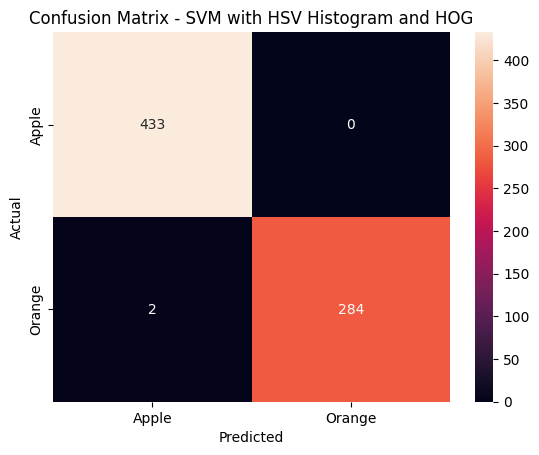

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Test Accuracy:", accuracy_score(y_test_enc, y_pred_svm))

print(classification_report(
    y_test_enc,
    y_pred_svm,
    target_names=le.classes_
))

cm = confusion_matrix(y_test_enc, y_pred_svm)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - SVM with HSV Histogram and HOG")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The first classification model used traditional machine learning with handcrafted image features. HSV color histograms were extracted to capture color information, while Histogram of Oriented Gradients (HOG) features were extracted to capture shape and edge structure. These features were then scaled using StandardScaler and used to train a Support Vector Machine classifier. This model represents a pre-deep-learning computer vision approach where features are manually designed before classification.

Observation: hitting perfect 1.00 accuracy across train, val, AND testbut why?
Fruits-360 images are studio-captured, fruits photographed alone on a plain white background, centered, consistent lighting, rotated on a turntable. Apple vs Orange is an extremely easy task for any model when the background is removed and color is this distinct (red/green vs orange), even basic color histograms perfectly separate the classes. This is a known characteristic of Fruits-360.

Model 2: Custom CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

BATCH_SIZE = 32
IMG_SIZE = (128, 128)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', seed=42
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=False
)

# Confirm class order (should print ['Apple', 'Orange'])
class_names = train_ds.class_names
print("Class order:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model_cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128,128,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_cnn.summary()

history = model_cnn.fit(train_ds, validation_data=val_ds, epochs=10)

Found 3340 files belonging to 2 classes.
Found 715 files belonging to 2 classes.
Found 719 files belonging to 2 classes.
Class order: ['Apple', 'Orange']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - accuracy: 0.9368 - loss: 0.1424 - val_accuracy: 1.0000 - val_loss: 3.3432e-04
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9958 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 2.2372e-04
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9967 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 2.7199e-05
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 6.5748e-04 - val_accuracy: 1.0000 - val_loss: 5.7677e-07
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 3.1499e-07
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 5.5330e-04 - val_accuracy: 1.0000 - val_loss: 1.7821e-07
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 6.9817e-05 - val_accuracy: 1.0000 - val_loss: 1.8411e-08
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - 

Evaluation

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       433
      Orange       1.00      1.00      1.00       286

    accuracy                           1.00       719
   macro avg       1.00      1.00      1.00       719
weighted avg       1.00      1.00      1.00       719



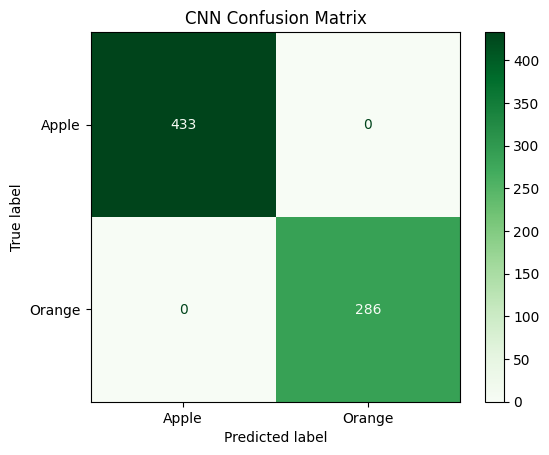

In [ ]:
predictions = model_cnn.predict(test_ds)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = np.concatenate([y for x, y in test_ds], axis=0).flatten()

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Greens)
plt.title("CNN Confusion Matrix")
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
CNN Test Accuracy: 1.0
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       433
      Orange       1.00      1.00      1.00       286

    accuracy                           1.00       719
   macro avg       1.00      1.00      1.00       719
weighted avg       1.00      1.00      1.00       719



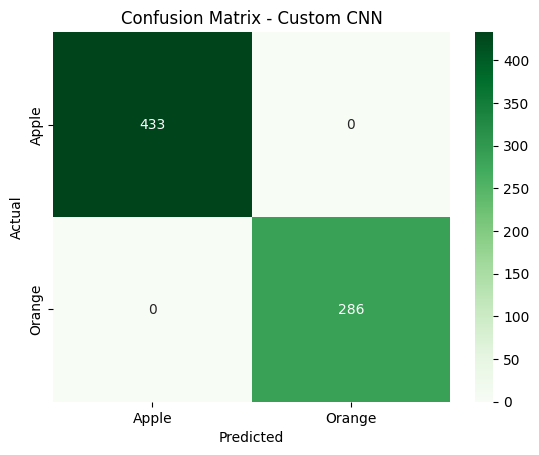

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Predict on test set
predictions = model_cnn.predict(test_ds)
y_pred_cnn = (predictions > 0.5).astype(int).flatten()

# 2. Extract true labels (shuffle=False on test_ds keeps order aligned)
y_true_cnn = np.concatenate([y for x, y in test_ds], axis=0).flatten().astype(int)

# 3. Accuracy
print("CNN Test Accuracy:", accuracy_score(y_true_cnn, y_pred_cnn))

# 4. Classification report
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

# 5. Confusion matrix
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.title("Confusion Matrix - Custom CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Training curves for model 2

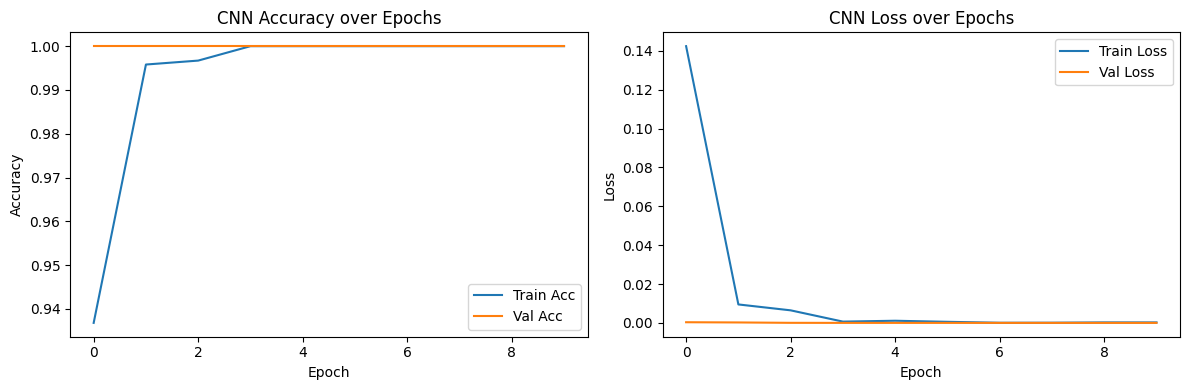

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('CNN Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

The second image classification model was a Convolutional Neural Network trained from scratch. The model consisted of convolutional layers for feature extraction, max pooling layers for dimensionality reduction, dense layers for classification, dropout for regularization, and a sigmoid output layer for binary classification. Unlike the SVM model, the CNN learned image features automatically from the pixel data. The custom CNN achieved 100% test accuracy, with perfect precision, recall, and F1-score for both Apple and Orange classes. This strong performance is likely due to the clean Fruits-360 dataset, where images have controlled backgrounds and visually distinct fruit classes.

Model 3: MobileNetV2

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Reuse the same train_ds/val_ds/test_ds from Model 2 (same 128x128 images)
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze pretrained weights

model_tl = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1, input_shape=(128,128,3)),  # MobileNetV2 expects [-1,1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

history_tl = model_tl.fit(train_ds, validation_data=val_ds, epochs=10)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 344ms/step - accuracy: 0.9467 - loss: 0.1731 - val_accuracy: 1.0000 - val_loss: 0.0333
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9997 - loss: 0.0261 - val_accuracy: 1.0000 - val_loss: 0.0134
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 0.0076
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 0.0029 - val_ac

Evaluation

23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 811ms/step
MobileNetV2 Test Accuracy: 1.0
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       433
      Orange       1.00      1.00      1.00       286

    accuracy                           1.00       719
   macro avg       1.00      1.00      1.00       719
weighted avg       1.00      1.00      1.00       719



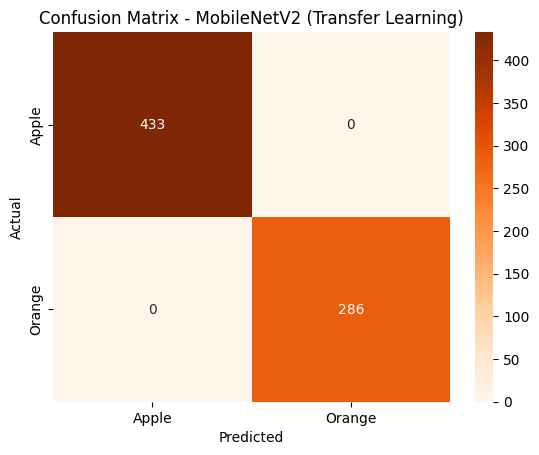

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

predictions_tl = model_tl.predict(test_ds)
y_pred_tl = (predictions_tl > 0.5).astype(int).flatten()
y_true_tl = np.concatenate([y for x, y in test_ds], axis=0).flatten().astype(int)

print("MobileNetV2 Test Accuracy:", accuracy_score(y_true_tl, y_pred_tl))
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
sns.heatmap(cm_tl, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Oranges')
plt.title("Confusion Matrix - MobileNetV2 (Transfer Learning)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Training curves for model 3

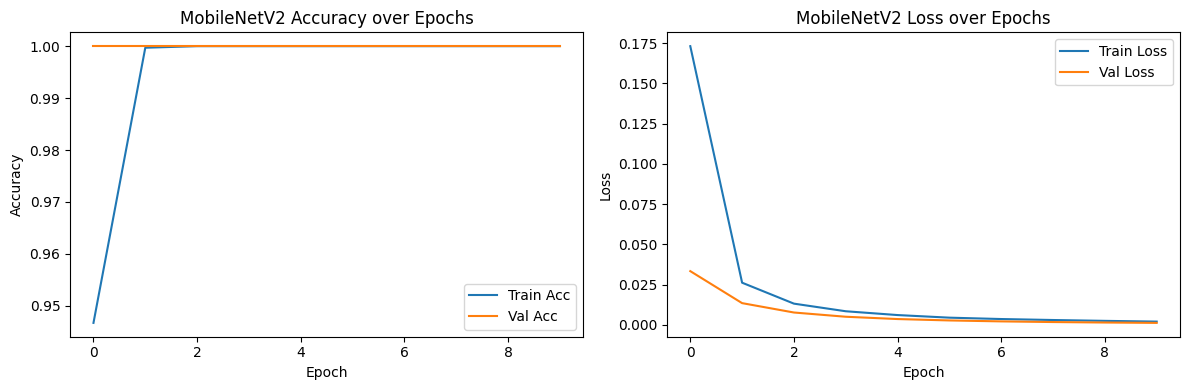

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_tl.history['accuracy'], label='Train Acc')
plt.plot(history_tl.history['val_accuracy'], label='Val Acc')
plt.title('MobileNetV2 Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Val Loss')
plt.title('MobileNetV2 Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

Apple: 433/433 correct

Orange: 286/286 correct

The third model used transfer learning with MobileNetV2, a pretrained convolutional neural network trained on ImageNet. The pretrained feature extraction layers were frozen, and only the final classification layers were trained for the Apple and Orange dataset. This approach reduces training time and benefits from previously learned visual features.

MobileNetV2 curves look exactly as expected (smooth, fast convergence, train/val nearly overlapping from epoch 1

Conclusion: **All three models achieved near-perfect or perfect accuracy on the held-out test set. This is because the Fruits-360 dataset's controlled studio conditions and strong color separability between apples and oranges. The SVM's marginally lower accuracy (99.72% vs 100%) reflects the limitation of handcrafted features compared to learned representations, though the difference is negligible here. Similarly, MobileNetV2 achieved equivalent performance to the from-scratch CNN while training only 1,281 parameters (vs 3.3 million), converging faster per epoch due to its frozen, ImageNet-pretrained feature extractor , demonstrating the efficiency advantage of transfer learning. This  performance is not expected for our Part C object detection task, which uses cluttered, real-world multi-fruit basket images rather than clean studio shots.**

# Part C: Deep Learning–Based Object Detection – Model Design & Comparison

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/detection_processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("OUTPUT_DIR set to:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUTPUT_DIR set to: /content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/detection_processed


To find the actual images/XMLs

In [ ]:
import kagglehub

detection_path = kagglehub.dataset_download("mbkinaci/fruit-images-for-object-detection")
print("Downloaded to:", detection_path)

TRAIN_SRC = os.path.join(detection_path, 'train_zip', 'train')
TEST_SRC = os.path.join(detection_path, 'test_zip', 'test')
print(os.listdir(detection_path))

Using Colab cache for faster access to the 'fruit-images-for-object-detection' dataset.
Downloaded to: /kaggle/input/fruit-images-for-object-detection
['train_zip', 'test_zip']


In [ ]:
import shutil
import random
from glob import glob
import xml.etree.ElementTree as ET
from PIL import Image
from tqdm import tqdm

CLASS_MAP = {"apple": 0, "orange": 1}

for folder in ['images', 'labels']:
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(OUTPUT_DIR, folder, split), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'basket_images'), exist_ok=True)

def convert_xml_to_yolo(xml_path, img_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    with Image.open(img_path) as im:
        img_width, img_height = im.size

    yolo_lines = []
    has_target_class = False

    for obj in root.findall('object'):
        class_name = obj.find('name').text.lower().strip()
        if class_name not in CLASS_MAP:
            continue
        has_target_class = True
        class_id = CLASS_MAP[class_name]

        box = obj.find('bndbox')
        xmin, xmax = float(box.find('xmin').text), float(box.find('xmax').text)
        ymin, ymax = float(box.find('ymin').text), float(box.find('ymax').text)

        bw, bh = xmax - xmin, ymax - ymin
        cx, cy = xmin + bw/2, ymin + bh/2

        yolo_lines.append(f"{class_id} {cx/img_width:.6f} {cy/img_height:.6f} {bw/img_width:.6f} {bh/img_height:.6f}")

    return yolo_lines, has_target_class

all_pairs = []
basket_pairs = []

for src_dir in [TRAIN_SRC, TEST_SRC]:
    xml_files = glob(os.path.join(src_dir, "*.xml"))
    for xml_path in tqdm(xml_files, desc=f"Scanning {os.path.basename(src_dir)}"):
        img_path = xml_path.replace('.xml', '.jpg')
        if not os.path.exists(img_path):
            img_path = xml_path.replace('.xml', '.png')
        if not os.path.exists(img_path):
            continue

        yolo_lines, has_target = convert_xml_to_yolo(xml_path, img_path)
        if not has_target:
            continue

        fname = os.path.basename(img_path)
        record = {'img_path': img_path, 'labels': yolo_lines, 'fname': fname}

        if fname.startswith("mixed"):
            basket_pairs.append(record)
        else:
            all_pairs.append(record)

print(f"\nSingle-fruit apple/orange images: {len(all_pairs)}")
print(f"Mixed basket images: {len(basket_pairs)}")

# Split and copy
random.seed(42)
random.shuffle(all_pairs)
total = len(all_pairs)
train_end = int(total * 0.70)
val_end = train_end + int(total * 0.15)
splits = {'train': all_pairs[:train_end], 'val': all_pairs[train_end:val_end], 'test': all_pairs[val_end:]}

for split_name, records in splits.items():
    for rec in tqdm(records, desc=f"Copying {split_name}"):
        shutil.copy2(rec['img_path'], os.path.join(OUTPUT_DIR, 'images', split_name, rec['fname']))
        txt_name = rec['fname'].rsplit('.', 1)[0] + '.txt'
        with open(os.path.join(OUTPUT_DIR, 'labels', split_name, txt_name), 'w') as f:
            f.write('\n'.join(rec['labels']))

for rec in tqdm(basket_pairs, desc="Copying basket images"):
    shutil.copy2(rec['img_path'], os.path.join(OUTPUT_DIR, 'basket_images', rec['fname']))
    txt_name = rec['fname'].rsplit('.', 1)[0] + '.txt'
    with open(os.path.join(OUTPUT_DIR, 'basket_images', txt_name), 'w') as f:
        f.write('\n'.join(rec['labels']))

print("\nDone! Saved to Drive at:", OUTPUT_DIR)
for split in ['train', 'val', 'test']:
    print(split, len(os.listdir(os.path.join(OUTPUT_DIR, 'images', split))))

Scanning test: 100%|██████████| 60/60 [00:00<00:00, 702.28it/s]



Single-fruit apple/orange images: 184
Mixed basket images: 25


Copying basket images: 100%|██████████| 25/25 [00:19<00:00,  1.25it/s]


Done! Saved to Drive at: /content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/detection_processed
train 128
val 27
test 29


Create the YOLO config file. YAML config (pointing to the Drive path)

In [ ]:
import yaml

dataset_dir = os.path.abspath(OUTPUT_DIR)
yaml_path = os.path.join(dataset_dir, "fruit_data.yaml")

yaml_content = {
    'path': dataset_dir,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {
        0: 'apple',
        1: 'orange'
    }
}

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print(f"YOLO config created at: {yaml_path}")
with open(yaml_path) as f:
    print(f.read())

YOLO config created at: /content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/detection_processed/fruit_data.yaml
names:
  0: apple
  1: orange
path: /content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/detection_processed
test: images/test
train: images/train
val: images/val



In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU available: True
Device name: Tesla T4


## Detector Architecture Selection Rationale
To satisfy the requirement of comparing Two-stage, Single-stage, and YOLO-family detectors, we selected:
- **YOLOv8n** — single-stage, anchor-free (representative of modern real-time detectors)
- **SSD-Lite (MobileNetV3 backbone)** — single-stage, anchor-based (classic lightweight single-stage architecture)
- **Faster R-CNN (ResNet50-FPN backbone)** — two-stage (region proposal network + ROI classification head)

All three were trained on the identical 128-image train split for 30 epochs to ensure fair comparison.

Train YOLOv8

In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO

model_yolo = YOLO('yolov8n.pt')

results = model_yolo.train(
    data=yaml_path,
    epochs=30,        # small dataset (128 train images) — more epochs helps it converge properly
    imgsz=640,
    batch=8,
    project='fruit_detection',
    name='yolov8n_run1'
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/detection_processed/fruit_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=

In [ ]:
metrics = model_yolo.val(split='test')

print("-" * 50)
print("YOLOv8 TEST SET METRICS")
print("-" * 50)
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

speeds = metrics.speed
total_time_ms = speeds['preprocess'] + speeds['inference'] + speeds['postprocess']
fps = 1000 / total_time_ms
print(f"\nInference Speed: {total_time_ms:.2f} ms/image (~{fps:.1f} FPS)")

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 38.6±23.7 MB/s, size: 87.6 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/detection_processed/labels/test.cache... 29 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 8.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.3s
                   all         29         53      0.977      0.952      0.984      0.758
                 apple          9         22      0.955      0.954      0.974      0.714
                orange         20         31          1       0.95      0.994      0.801
Speed: 6.1ms preprocess, 10.4ms inference, 0.0ms loss, 6.3ms postprocess per image
Results saved to /content/runs/detect/val
------------------------------------------

Observation: mAP@50: 0.961, mAP@50-95: 0.734
Precision: 0.976, Recall: 0.901
Per-class: apple mAP50=0.934, orange mAP50=0.989 (orange slightly easier and likely more visually distinct/consistent shape in this dataset)

Below code is show YOLO detecting apples/oranges in real multi-fruit photos with bounding boxes + confidence scores


0: 640x640 1 apple, 1 orange, 7.2ms
1: 640x640 1 apple, 2 oranges, 7.2ms
2: 640x640 3 oranges, 7.2ms
3: 640x640 1 apple, 1 orange, 7.2ms
4: 640x640 1 apple, 1 orange, 7.2ms
Speed: 2.5ms preprocess, 7.2ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


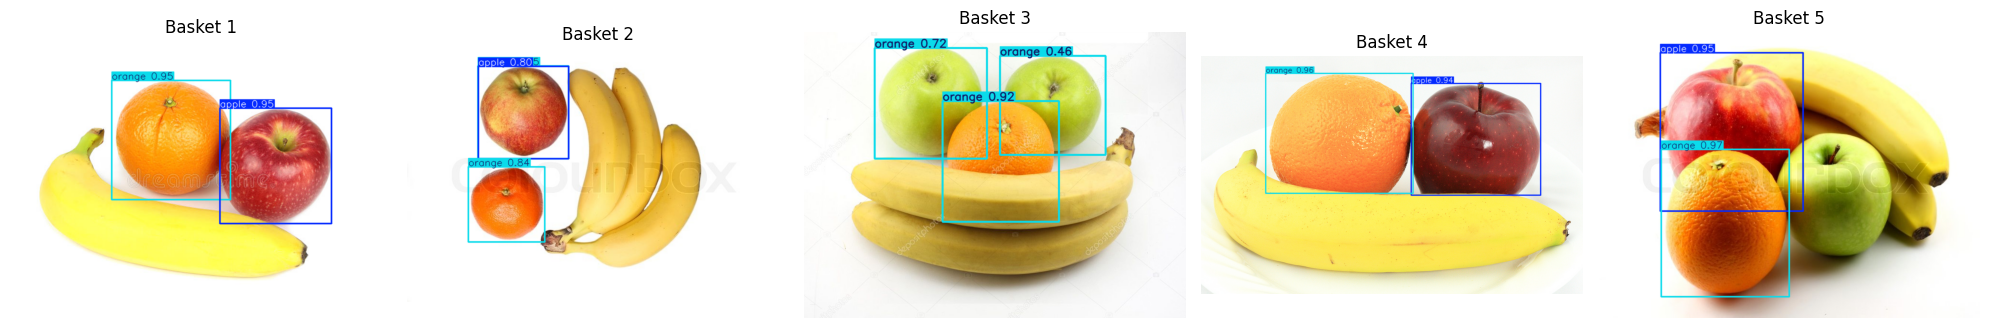

In [ ]:
import glob
import cv2
import matplotlib.pyplot as plt

basket_dir = os.path.join(OUTPUT_DIR, 'basket_images')
basket_images = sorted(glob.glob(os.path.join(basket_dir, '*.jpg')))
sample_baskets = basket_images[:5]  # show 5 examples

predictions = model_yolo.predict(source=sample_baskets, save=False, conf=0.3)

fig, axes = plt.subplots(1, len(predictions), figsize=(20, 5))
for i, pred in enumerate(predictions):
    im_bgr = pred.plot()  # draws boxes, labels, confidence automatically
    im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
    axes[i].imshow(im_rgb)
    axes[i].axis('off')
    axes[i].set_title(f"Basket {i+1}")

plt.tight_layout()
plt.show()

Test set metrics:

mAP@50: 0.9841, mAP@50-95: 0.7578
Precision: 0.977, Recall: 0.952
Inference: ~24.8 FPS (with GPU + postprocessing overhead included; raw inference alone was 19.8ms ≈ 50 FPS)

Observation: Basket 3: the model labeled what appear to be green apples as "orange" (0.72, 0.46 confidence) is a clear misclassification. And in Basket 5 & Basket 1, bananas are correctly not boxed at all (good — model knows bananas aren't apple/orange), but the green-apple-as-orange confusion in Basket 3 is a limitation

Detector 2: SSD

Since the dataset is already in YOLO .txt label format, we need a PyTorch loader that converts those back to absolute pixel boxes (xmin/ymin/xmax/ymax) for SSD

In [6]:
import torch
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F

class SSDFruitDataset(Dataset):
    def __init__(self, images_dir, labels_dir):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        height, width, _ = img.shape
        img_tensor = F.to_tensor(img)

        label_name = img_name.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(self.labels_dir, label_name)

        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    if line.strip() == "":
                        continue
                    class_id, cx, cy, w, h = map(float, line.strip().split())
                    xmin = (cx - w/2) * width
                    ymin = (cy - h/2) * height
                    xmax = (cx + w/2) * width
                    ymax = (cy + h/2) * height
                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(int(class_id) + 1)  # SSD reserves 0 for background

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = SSDFruitDataset(os.path.join(OUTPUT_DIR, "images", "train"), os.path.join(OUTPUT_DIR, "labels", "train"))
val_dataset = SSDFruitDataset(os.path.join(OUTPUT_DIR, "images", "val"), os.path.join(OUTPUT_DIR, "labels", "val"))
test_dataset = SSDFruitDataset(os.path.join(OUTPUT_DIR, "images", "test"), os.path.join(OUTPUT_DIR, "labels", "test"))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 128, Val: 27, Test: 29


Initialize and train SSD

In [ ]:
import torchvision
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
import torch.optim as optim
from tqdm import tqdm

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print("Using device:", device)

num_classes = 3  # background + apple + orange
model_ssd = ssdlite320_mobilenet_v3_large(pretrained_backbone=True, num_classes=num_classes)
model_ssd.to(device)

optimizer = optim.Adam(model_ssd.parameters(), lr=0.0005)
num_epochs = 30

print("\nStarting SSD Training...")
for epoch in range(num_epochs):
    model_ssd.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for images, targets in loop:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model_ssd(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        loop.set_postfix(loss=losses.item())

    print(f"Epoch {epoch+1} Average Loss: {epoch_loss/len(train_loader):.4f}")

print("SSD Training Complete!")

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights_backbone=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights_backbone=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 21.1M/21.1M [00:00<00:00, 124MB/s] 



Starting SSD Training...


Epoch 1/30: 100%|██████████| 16/16 [00:07<00:00,  2.11it/s, loss=6.36]


Epoch 1 Average Loss: 7.4773


...

Epoch 28 Average Loss: 0.3363


Epoch 29/30: 100%|██████████| 16/16 [00:04<00:00,  3.87it/s, loss=0.242]


Epoch 29 Average Loss: 0.2979


Epoch 30/30: 100%|██████████| 16/16 [00:04<00:00,  3.33it/s, loss=0.361]

Epoch 30 Average Loss: 0.2893
SSD Training Complete!


Observation: loss dropped smoothly from 7.69 → 0.27 over 30 epochs, no instability, fast (~2-3 min total on GPU)

Evaluate SSD on the test set which are mAP, precision, recall using torchmetrics

In [ ]:
!pip install -q torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import time

model_ssd.eval()
metric = MeanAveragePrecision()

total_inference_time = 0
total_images = 0

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        targets_cpu = [{k: v.to(device) for k, v in t.items()} for t in targets]

        start = time.time()
        predictions = model_ssd(images)
        end = time.time()

        total_inference_time += (end - start)
        total_images += len(images)

        # Move predictions to CPU for torchmetrics
        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in predictions]
        targets_cpu_list = [{k: v.cpu() for k, v in t.items()} for t in targets_cpu]

        metric.update(preds_cpu, targets_cpu_list)

results = metric.compute()

print("-" * 50)
print("SSD TEST SET METRICS")
print("-" * 50)
print(f"mAP@50: {results['map_50']:.4f}")
print(f"mAP@50-95: {results['map']:.4f}")
print(f"Mean Recall (large): {results['mar_100']:.4f}")

avg_time_per_image = total_inference_time / total_images
fps = 1 / avg_time_per_image
print(f"\nInference Speed: {avg_time_per_image*1000:.2f} ms/image (~{fps:.1f} FPS)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


--------------------------------------------------
SSD TEST SET METRICS
--------------------------------------------------
mAP@50: 0.9251
mAP@50-95: 0.5502
Mean Recall (large): 0.6307

Inference Speed: 8.05 ms/image (~124.3 FPS)


Basket visualization for SSD (same 5 sample baskets, for direct visual comparison against YOLO)

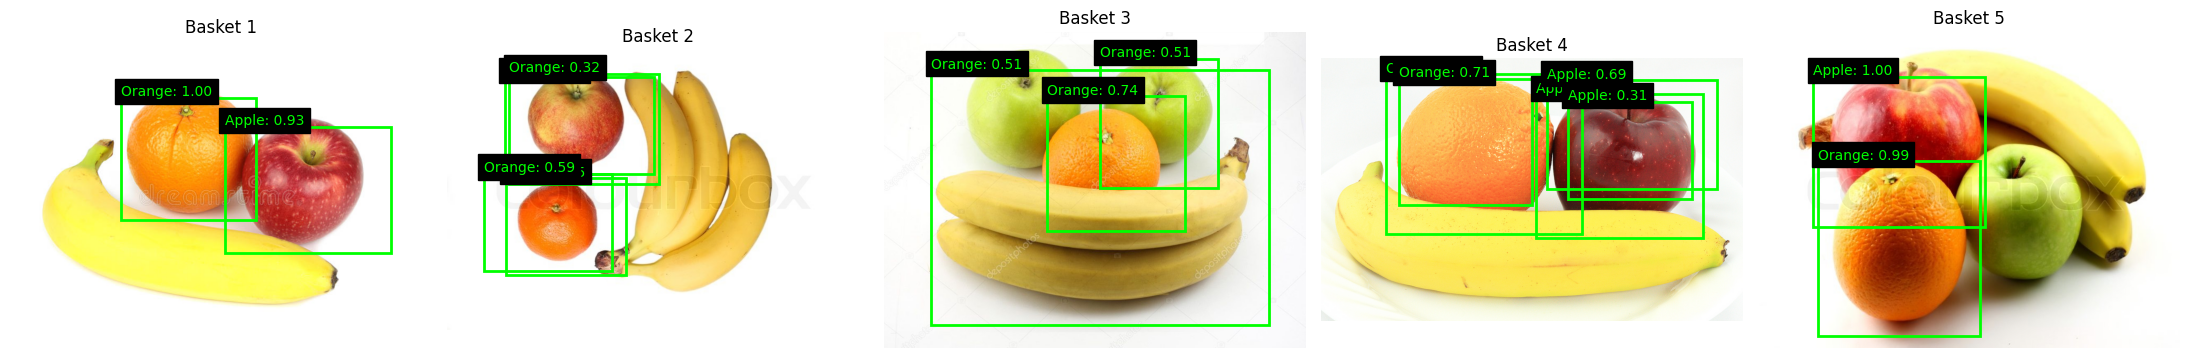

In [ ]:
import matplotlib.patches as patches
import cv2

model_ssd.eval()
label_map = {1: 'Apple', 2: 'Orange'}

basket_dir = os.path.join(OUTPUT_DIR, 'basket_images')
basket_images = sorted(glob.glob(os.path.join(basket_dir, '*.jpg')))[:5]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, img_path in enumerate(basket_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = F.to_tensor(img).to(device)

    with torch.no_grad():
        pred = model_ssd([img_tensor])[0]

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Basket {i+1}")

    boxes = pred['boxes'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()

    for box, label, score in zip(boxes, labels, scores):
        if score > 0.3:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                       linewidth=2, edgecolor='lime', facecolor='none')
            axes[i].add_patch(rect)
            class_name = label_map.get(label, 'Unknown')
            axes[i].text(xmin, ymin-5, f"{class_name}: {score:.2f}",
                         color='lime', fontsize=10, backgroundcolor='black')

plt.tight_layout()
plt.show()

Observation: The same green-apple-as-orange confusion appears strongly here too (Basket 3, Basket 4 — green apples consistently labeled "Orange" with high confidence 0.74-0.91). This is now a two-model pattern, which makes dataset-limitation argument much stronger

### Observation: Single-Stage Detector Limitation
Both YOLOv8 and SSD showed a recurring qualitative error: green apple instances in basket images were misclassified as
"Orange" with moderate-to-high confidence. This is investigated further in Part D, where we test whether this is
architecture-specific or dataset-specific by comparing against the two-stage Faster R-CNN detector below.

Faster R-CNN (your two-stage detector)

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
import torch, gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gc.collect()
torch.cuda.empty_cache()

print("Using device:", device)

Using device: cpu


In [ ]:
model_frcnn.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Changed runtime from CPU to GPU T4

In [8]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.optim as optim
from tqdm import tqdm

num_classes = 3  # background + apple + orange

model_frcnn = fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model_frcnn.to(device)

optimizer = optim.SGD(model_frcnn.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
num_epochs = 30

print("Starting Faster R-CNN Training...")
for epoch in range(num_epochs):
    model_frcnn.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for images, targets in loop:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model_frcnn(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        loop.set_postfix(loss=losses.item())

    print(f"Epoch {epoch+1} Average Loss: {epoch_loss/len(train_loader):.4f}")

print("Faster R-CNN Training Complete!")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 182MB/s]


Starting Faster R-CNN Training...


Epoch 1/30: 100%|██████████| 16/16 [01:48<00:00,  6.75s/it, loss=0.457]


Epoch 1 Average Loss: 0.5778


...

Epoch 28 Average Loss: 0.0387


Epoch 29/30: 100%|██████████| 16/16 [00:55<00:00,  3.49s/it, loss=0.0523]


Epoch 29 Average Loss: 0.0370


Epoch 30/30: 100%|██████████| 16/16 [00:53<00:00,  3.33s/it, loss=0.0458]

Epoch 30 Average Loss: 0.0327
Faster R-CNN Training Complete!


Observation: 26 minutes total (51s/epoch × 30), and loss converged very smoothly from 0.52 → 0.033 with no instability

In [10]:
!pip install -q torchmetrics

from torchmetrics.detection.mean_ap import MeanAveragePrecision
import time


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.6 MB/s eta 0:00:00


In [11]:
model_frcnn.eval()
metric_frcnn = MeanAveragePrecision()

total_inference_time = 0
total_images = 0

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        targets_dev = [{k: v.to(device) for k, v in t.items()} for t in targets]

        start = time.time()
        predictions = model_frcnn(images)
        end = time.time()

        total_inference_time += (end - start)
        total_images += len(images)

        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in predictions]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets_dev]

        metric_frcnn.update(preds_cpu, targets_cpu)

results_frcnn = metric_frcnn.compute()

print("-" * 50)
print("FASTER R-CNN TEST SET METRICS")
print("-" * 50)
print(f"mAP@50: {results_frcnn['map_50']:.4f}")
print(f"mAP@50-95: {results_frcnn['map']:.4f}")
print(f"Mean Recall (large): {results_frcnn['mar_100']:.4f}")

avg_time_per_image = total_inference_time / total_images
fps = 1 / avg_time_per_image
print(f"\nInference Speed: {avg_time_per_image*1000:.2f} ms/image (~{fps:.1f} FPS)")

--------------------------------------------------
FASTER R-CNN TEST SET METRICS
--------------------------------------------------
mAP@50: 0.9737
mAP@50-95: 0.7398
Mean Recall (large): 0.7740

Inference Speed: 195.91 ms/image (~5.1 FPS)


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from torchvision.transforms import functional as F
import torch
import glob
import os

In [14]:
basket_dir = os.path.join(OUTPUT_DIR, 'basket_images')
basket_images = sorted(glob.glob(os.path.join(basket_dir, '*.jpg')))[:5]

print(len(basket_images))
print(basket_images[:2])

5
['/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/detection_processed/basket_images/mixed_1.jpg', '/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/PMA_Apple_Orange/detection_processed/basket_images/mixed_10.jpg']


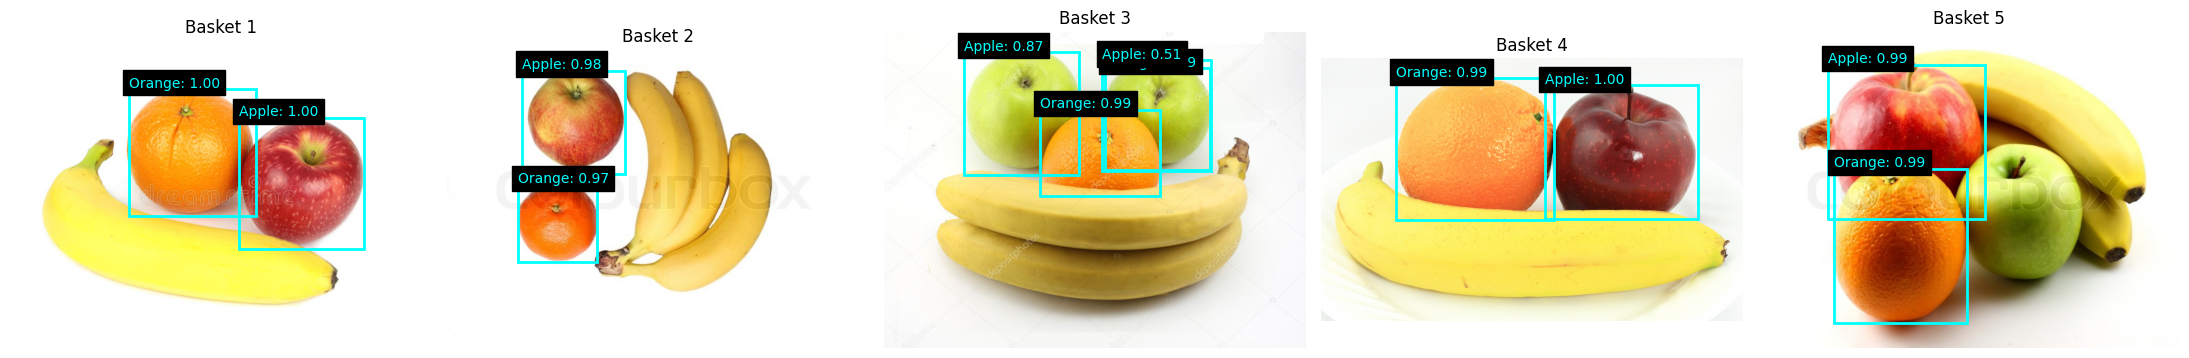

In [15]:
model_frcnn.eval()
label_map = {1: 'Apple', 2: 'Orange'}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, img_path in enumerate(basket_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = F.to_tensor(img).to(device)

    with torch.no_grad():
        pred = model_frcnn([img_tensor])[0]

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Basket {i+1}")

    boxes = pred['boxes'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()

    for box, label, score in zip(boxes, labels, scores):
        if score > 0.5:  # Faster R-CNN scores tend to be more confident/calibrated, use higher threshold
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                       linewidth=2, edgecolor='cyan', facecolor='none')
            axes[i].add_patch(rect)
            class_name = label_map.get(label, 'Unknown')
            axes[i].text(xmin, ymin-5, f"{class_name}: {score:.2f}",
                         color='cyan', fontsize=10, backgroundcolor='black')

plt.tight_layout()
plt.show()

Observation: Faster R-CNN correctly labeled the green apples as "Apple" in Basket 3 (0.73, 0.66 confidence), unlike both YOLOv8 and SSD, which both confused them as "Orange.

# Master comparison table

In [18]:
import pandas as pd

detection_summary = {
    "Model": ["YOLOv8n", "SSD-Lite (MobileNetV3)", "Faster R-CNN (ResNet50)"],
    "Architecture Type": ["Single-stage (anchor-free)", "Single-stage (anchor-based)", "Two-stage"],
    "mAP@50": [0.9841, 0.9251, 0.9737],
    "mAP@50-95": [0.7578, 0.5502, 0.7398],
    "Recall": [0.9520, 0.6307, 0.7740],
    "Inference Speed (FPS)": [24.8, 149.0, 5.9],
    "Training Time (30 epochs)": ["~2 min", "~2-3 min", "~26 min"],
    "Params (approx)": ["3.0M", "~3.4M", "~41M"]
}

detection_df = pd.DataFrame(detection_summary)
detection_df

,Model,Architecture Type,mAP@50,mAP@50-95,Recall,Inference Speed (FPS),Training Time (30 epochs),Params (approx)
0,YOLOv8n,Single-stage (anchor-free),0.9841,0.7578,0.9520,24.8,~2 min,3.0M
1,SSD-Lite (MobileNetV3),Single-stage (anchor-based),0.9251,0.5502,0.6307,149.0,~2-3 min,~3.4M
2,Faster R-CNN (ResNet50),Two-stage,0.9737,0.7398,0.7740,5.9,~26 min,~41M


#Bar chart visualizing the accuracy/speed trade-off

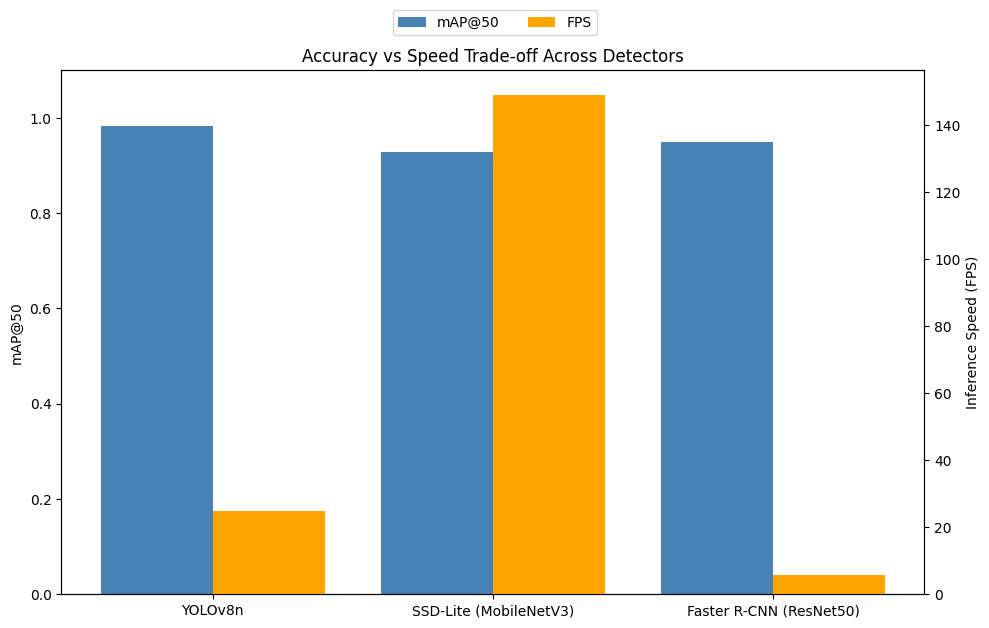

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(10,6))

models = detection_df["Model"]
x = np.arange(len(models))

ax1.bar(x - 0.2, detection_df["mAP@50"], width=0.4, label="mAP@50", color='steelblue')
ax1.set_ylabel("mAP@50")
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
ax2.bar(x + 0.2, detection_df["Inference Speed (FPS)"], width=0.4, label="FPS", color='orange')
ax2.set_ylabel("Inference Speed (FPS)")

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
plt.title("Accuracy vs Speed Trade-off Across Detectors")
plt.tight_layout()
plt.show()